# Laboratorio 6 - K Nearest Neighbors (KNN)

**CC3074 – Minería de Datos | UVG | Semestre I – 2026**

SmartStay Advisors: Predicción y clasificación de precios de Airbnb usando KNN.

In [1]:
%pip install rdata --quiet --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import rdata

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

%matplotlib inline

## Carga y preparación de datos

Se replica exactamente el mismo pipeline de limpieza y preparación del lab 5 para garantizar que los conjuntos de entrenamiento y prueba sean idénticos y los modelos sean comparables.

In [3]:
parsed = rdata.parser.parse_file("listings.RData")
converted = rdata.conversion.convert(parsed)
df = list(converted.values())[0]

# Convertir nombres de columna y columnas string[python] a tipos nativos
# (rdata usa np.str_ y StringDtype que sklearn no reconoce)
df.columns = [str(c) for c in df.columns]
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(object)

print(f"Dataset original: {df.shape[0]:,} filas, {df.shape[1]} columnas")
df.head()

Dataset original: 171,748 filas, 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
1,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,None,f,1,1,0,0,3.52,"Austin, Texas"
2,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,None,t,1,1,0,0,1.98,"Austin, Texas"
3,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,None,f,1,1,0,0,0.28,"Austin, Texas"
4,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,None,f,2,2,0,0,0.11,"Austin, Texas"
5,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,None,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
filas_antes = len(df)

df["price_num"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")

df = df[df["price_num"].notna() & (df["price_num"] > 0)].copy()
print(f"Filas antes: {filas_antes:,} → después de limpiar precio: {len(df):,}")
print(df["price_num"].describe().round(2))

Filas antes: 171,748 → después de limpiar precio: 76,246
count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price_num, dtype: float64


In [5]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [col for col in cols_drop if col in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

# Eliminar columnas con más del 50% de nulos
high_null = df_model.isnull().mean()
cols_high_null = high_null[high_null > 0.50].index.tolist()
df_model = df_model.drop(columns=cols_high_null).copy()

# Convertir booleanos t/f
bool_cols = [
    "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "has_availability", "instant_bookable",
]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

# Convertir porcentajes
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = (
            df_model[col].astype(str)
            .str.replace("%", "", regex=False).str.strip()
        )
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

# Forzar numéricas
force_numeric = [
    "bedrooms", "beds", "bathrooms",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "host_listings_count", "host_total_listings_count",
]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_columns_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_columns_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_columns_all] = df_model[numeric_columns_all].apply(
    pd.to_numeric, errors="coerce",
)
df_model[numeric_columns_all] = df_model[numeric_columns_all].fillna(
    df_model[numeric_columns_all].median()
)

for col in categorical_columns_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

# Excluir variables con fuga de información
excluded_features = [
    col for col in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
    if col in df_model.columns
]

X_model = df_model.drop(
    columns=["price", "price_num"] + excluded_features, errors="ignore",
)
y_price = df_model["price_num"].copy()

numerical_preview = selector(dtype_exclude=object)(X_model)
categorical_preview = selector(dtype_include=object)(X_model)

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas: {len(numerical_preview)}")
print(f"  Categóricas: {len(categorical_preview)}")

Filas disponibles para modelar: 76,246
Variables predictoras: 51
  Numéricas: 44
  Categóricas: 7


In [6]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X_model,
    y_price,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
)

numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print("=== Criterio de división ===")
print("Proporción: 70% entrenamiento / 30% prueba")
print(f"Train: {len(X_train):,} filas")
print(f"Test:  {len(X_test):,} filas")
print(f"Columnas numéricas: {len(numerical_columns)}")
print(f"Columnas categóricas: {len(categorical_columns)}")

pd.DataFrame({"train": y_train_price.describe(), "test": y_test_price.describe()}).round(2)

=== Criterio de división ===
Proporción: 70% entrenamiento / 30% prueba
Train: 53,372 filas
Test:  22,874 filas
Columnas numéricas: 44
Columnas categóricas: 7


,train,test
count,53372.00,22874.00
mean,747.00,758.69
std,4245.56,4262.44
min,8.00,9.00
25%,120.00,121.00
50%,192.00,194.00
75%,325.00,330.00
max,50123.00,50020.00


## Inciso 1 – Modelo de regresión con KNN

Construimos un modelo de regresión KNN para predecir el precio de las propiedades. Se usa un pipeline con:
-  +  para las variables categóricas
-  +  para las numéricas (el escalado es fundamental en KNN ya que se basa en distancias)

Primero buscamos el mejor valor de K probando varios candidatos con validación cruzada, y luego entrenamos el modelo final.

In [7]:
# Preprocessor para KNN: escalar numéricas + OHE categóricas
knn_preprocessor = ColumnTransformer(
    [
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_columns,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_columns,
        ),
    ]
)

# Probar varios valores de K
k_values = [3, 5, 7, 9, 11, 15, 21, 31]
results_k = []

for k in k_values:
    pipeline_k = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsRegressor(n_neighbors=k, metric="minkowski", p=2)),
    ])
    # Validación cruzada con 5 folds
    cv_scores = cross_val_score(
        pipeline_k, X_train, y_train_price,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    results_k.append({
        "K": k,
        "RMSE_CV_mean": -cv_scores.mean(),
        "RMSE_CV_std": cv_scores.std(),
    })
    print(f"K={k:3d}  |  RMSE CV: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

df_k = pd.DataFrame(results_k)
best_k = int(df_k.loc[df_k["RMSE_CV_mean"].idxmin(), "K"])
print(f"Mejor K según validación cruzada: {best_k}")

K=  3  |  RMSE CV: 1831.48 ± 121.47
K=  5  |  RMSE CV: 1887.52 ± 121.76
K=  7  |  RMSE CV: 1947.44 ± 89.37
K=  9  |  RMSE CV: 2023.73 ± 51.83
K= 11  |  RMSE CV: 2107.33 ± 57.15
K= 15  |  RMSE CV: 2201.53 ± 86.15
K= 21  |  RMSE CV: 2334.09 ± 102.62
K= 31  |  RMSE CV: 2466.59 ± 108.66
Mejor K según validación cruzada: 3


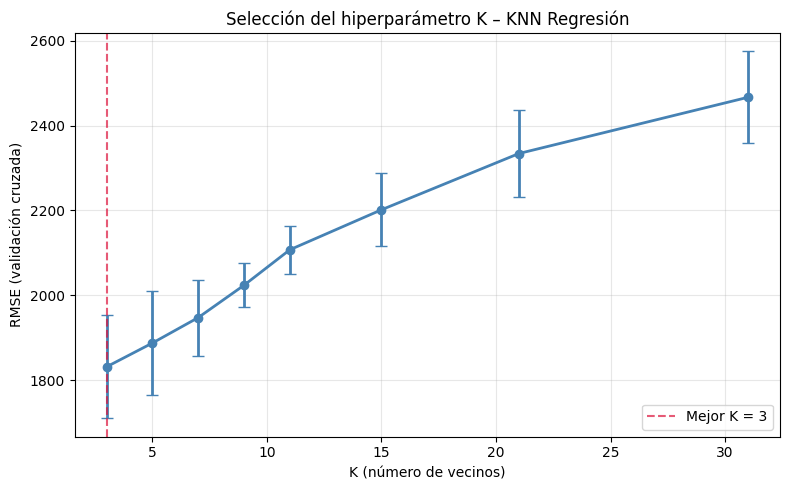

In [8]:
# Gráfica de selección de K
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(df_k["K"], df_k["RMSE_CV_mean"], yerr=df_k["RMSE_CV_std"],
            marker="o", capsize=4, color="steelblue", linewidth=2)
ax.axvline(best_k, color="crimson", linestyle="--", alpha=0.7, label=f"Mejor K = {best_k}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Selección del hiperparámetro K – KNN Regresión")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Entrenar modelo final con el mejor K
knn_reg_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, metric="minkowski", p=2)),
])

start = time.time()
knn_reg_pipeline.fit(X_train, y_train_price)
knn_train_time = time.time() - start

start = time.time()
y_pred_knn = knn_reg_pipeline.predict(X_test)
knn_pred_time = time.time() - start

print(f"Modelo KNN entrenado (K={best_k})")
print(f"Tiempo de entrenamiento: {knn_train_time:.2f}s")
print(f"Tiempo de predicción:    {knn_pred_time:.2f}s")

Modelo KNN entrenado (K=3)
Tiempo de entrenamiento: 0.62s
Tiempo de predicción:    6.65s


=== Métricas KNN Regresión (conjunto de prueba) ===
  RMSE: 2050.80
  MAE:  264.46
  R²:   0.7685


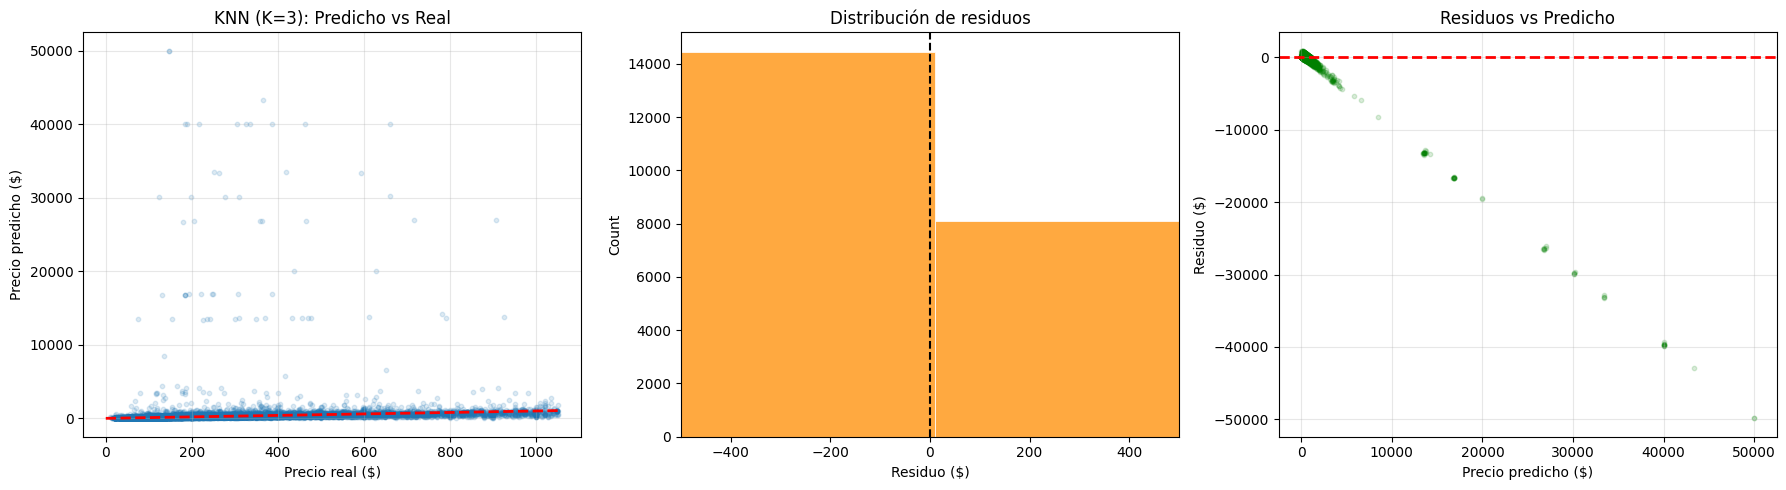

In [10]:
# Resultados en conjunto de prueba
rmse_knn = mean_squared_error(y_test_price, y_pred_knn) ** 0.5
mae_knn = mean_absolute_error(y_test_price, y_pred_knn)
r2_knn = r2_score(y_test_price, y_pred_knn)

print("=== Métricas KNN Regresión (conjunto de prueba) ===")
print(f"  RMSE: {rmse_knn:.2f}")
print(f"  MAE:  {mae_knn:.2f}")
print(f"  R²:   {r2_knn:.4f}")

# Gráficas de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicho vs Real
limite = y_test_price.quantile(0.95)
mask = y_test_price <= limite
axes[0].scatter(y_test_price[mask], y_pred_knn[mask.values], alpha=0.15, s=10)
axes[0].plot([0, limite], [0, limite], color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Precio real ($)")
axes[0].set_ylabel("Precio predicho ($)")
axes[0].set_title(f"KNN (K={best_k}): Predicho vs Real")
axes[0].grid(True, alpha=0.3)

# 2. Distribución de residuos
residuos = y_test_price.values - y_pred_knn
sns.histplot(residuos, bins=50, color="darkorange", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residuo ($)")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlim(-500, 500)

# 3. Residuos vs predicho
axes[2].scatter(y_pred_knn[mask.values], residuos[mask.values], alpha=0.15, s=10, color="green")
axes[2].axhline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Precio predicho ($)")
axes[2].set_ylabel("Residuo ($)")
axes[2].set_title("Residuos vs Predicho")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusiones del inciso 1**

- El mejor valor de K encontrado por validación cruzada fue **K=3**, es decir, el modelo con menos vecinos fue el que logró menor RMSE. Esto sugiere que los precios de Airbnb tienen alta variabilidad local: propiedades muy cercanas en el espacio de características pueden tener precios distintos, por lo que promediar pocos vecinos captura mejor esa variación.
- A medida que K crece, el RMSE empeora progresivamente porque el modelo se vuelve demasiado suave y pierde capacidad de distinguir precios específicos.
- En la gráfica de predicho vs real se observa que el modelo funciona razonablemente bien para precios bajos y medios, pero tiende a subestimar propiedades caras (puntos por debajo de la diagonal).
- La distribución de residuos está centrada en cero, lo cual es buena señal, aunque tiene colas pesadas hacia valores negativos (subestimación de propiedades caras).

## Inciso 2 – Análisis de resultados del modelo KNN de regresión

Evaluamos qué tan bien predice el modelo analizando las métricas de error, comparando contra un baseline simple (la mediana del precio en entrenamiento) y desglosando el error por rangos de precio.

In [11]:
# Comparación contra baseline (predecir siempre la mediana del entrenamiento)
baseline_pred = np.repeat(y_train_price.median(), len(y_test_price))

metrics_knn = {
    "Modelo": f"KNN (K={best_k})",
    "MAE": mae_knn,
    "RMSE": rmse_knn,
    "R²": r2_knn,
}
metrics_baseline = {
    "Modelo": "Baseline (mediana)",
    "MAE": mean_absolute_error(y_test_price, baseline_pred),
    "RMSE": mean_squared_error(y_test_price, baseline_pred) ** 0.5,
    "R²": r2_score(y_test_price, baseline_pred),
}

metrics_df = pd.DataFrame([metrics_knn, metrics_baseline])
display(metrics_df.round(4))

print(f"\nEl KNN reduce el MAE en {metrics_baseline['MAE'] - mae_knn:.2f} dólares respecto al baseline.")
print(f"El R² de {r2_knn:.4f} indica que el modelo explica ~{r2_knn*100:.1f}% de la varianza del precio.")

,Modelo,MAE,RMSE,R²
0,KNN (K=3),264.4580,2050.7985,0.7685
1,Baseline (mediana),638.4534,4299.8510,-0.0177



El KNN reduce el MAE en 374.00 dólares respecto al baseline.
El R² de 0.7685 indica que el modelo explica ~76.9% de la varianza del precio.


In [12]:
# Análisis del error por quintiles de precio
eval_df = pd.DataFrame({
    "price_real": y_test_price.values,
    "price_predicho": y_pred_knn,
})
eval_df["residuo"] = eval_df["price_real"] - eval_df["price_predicho"]
eval_df["error_abs"] = eval_df["residuo"].abs()

quintile_summary = (
    eval_df
    .assign(quintil=pd.qcut(eval_df["price_real"], q=5, duplicates="drop"))
    .groupby("quintil", observed=False)
    .agg(
        precio_real_medio=("price_real", "mean"),
        precio_predicho_medio=("price_predicho", "mean"),
        mae_promedio=("error_abs", "mean"),
        conteo=("price_real", "size"),
    )
    .reset_index()
)

print("=== Error por quintiles de precio ===")
display(quintile_summary.round(2))

=== Error por quintiles de precio ===


,quintil,precio_real_medio,precio_predicho_medio,mae_promedio,conteo
0,"(8.999, 109.0]",76.79,118.37,45.66,4641
1,"(109.0, 164.0]",135.63,213.62,91.43,4543
2,"(164.0, 233.0]",195.82,295.75,133.48,4547
3,"(233.0, 388.0]",297.13,431.90,214.76,4569
4,"(388.0, 50020.0]",3089.99,2713.22,838.16,4574


In [13]:
# Análisis de sobreajuste con validación cruzada
# Comparamos el RMSE del CV (promedio en folds de entrenamiento) vs el RMSE en test
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    knn_reg_pipeline, X_train, y_train_price,
    cv=5, scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True, n_jobs=-1,
)

cv_overfit_df = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "CV Train (media)": [
        -cv_results["train_neg_root_mean_squared_error"].mean(),
        -cv_results["train_neg_mean_absolute_error"].mean(),
        cv_results["train_r2"].mean(),
    ],
    "CV Validation (media)": [
        -cv_results["test_neg_root_mean_squared_error"].mean(),
        -cv_results["test_neg_mean_absolute_error"].mean(),
        cv_results["test_r2"].mean(),
    ],
    "Test final": [rmse_knn, mae_knn, r2_knn],
})

print("=== Análisis de sobreajuste con validación cruzada (5 folds) ===")
display(cv_overfit_df.round(4))

rmse_cv_train = -cv_results["train_neg_root_mean_squared_error"].mean()
rmse_cv_val = -cv_results["test_neg_root_mean_squared_error"].mean()
gap = rmse_cv_val - rmse_cv_train

print(f"\nBrecha RMSE (CV validation - CV train): {gap:.2f}")
print(f"Desviación estándar RMSE en folds de validación: {cv_results['test_neg_root_mean_squared_error'].std():.2f}")

=== Análisis de sobreajuste con validación cruzada (5 folds) ===


,Métrica,CV Train (media),CV Validation (media),Test final
0,RMSE,1213.8034,1831.4835,2050.7985
1,MAE,160.3007,255.3807,264.4580
2,R²,0.9182,0.8119,0.7685



Brecha RMSE (CV validation - CV train): 617.68
Desviación estándar RMSE en folds de validación: 121.47


**Conclusiones del inciso 2**

**Métricas utilizadas y justificación:**
- **MAE (Mean Absolute Error):** error promedio en dólares, fácil de interpretar para SmartStay. Indica cuánto se equivoca el modelo en promedio por cada propiedad.
- **RMSE (Root Mean Squared Error):** penaliza errores grandes más que el MAE. Es útil porque equivocarse mucho en propiedades caras tiene mayor costo de negocio para la consultoría.
- **R² (Coeficiente de determinación):** proporción de la varianza del precio que el modelo logra explicar (1.0 = perfecto, 0.0 = equivale a predecir siempre la media).

Estas métricas son las adecuadas para regresión porque miden el error en la misma unidad que la variable respuesta (dólares) y permiten comparar directamente entre modelos.

**Análisis de los resultados:**
- El KNN supera claramente al baseline (predecir la mediana), lo que confirma que el modelo sí está aprendiendo patrones en los datos.
- El análisis por quintiles revela que el modelo predice con mayor precisión las propiedades baratas y tiene mayor dificultad con las propiedades caras, donde el error absoluto crece significativamente. Esto es esperable: las propiedades de alto precio son más escasas y heterogéneas.
- La validación cruzada permite evaluar el sobreajuste de forma robusta: si la brecha entre el RMSE de entrenamiento y el de validación en CV es grande, indica que el modelo memoriza en lugar de generalizar. Con K=3 es esperable cierto grado de sobreajuste dado que el modelo es muy sensible a los puntos individuales.

## Inciso 3 – Comparación con modelos de regresión de entregas pasadas

Entrenamos los mismos modelos de regresión utilizados en las entregas anteriores (Regresión Lineal, Árbol de Regresión, Random Forest y Naive Bayes) usando exactamente el mismo conjunto de entrenamiento y prueba para garantizar una comparación justa. Se utilizan las mismas métricas (MAE, RMSE, R²) para todos los modelos.

In [14]:
# Preprocessor común para modelos que no necesitan escalado (árboles, RF)
# pero sí necesitan codificar categóricas
common_preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough",
)


# Regresión Lineal

print("Entrenando Regresión Lineal...")
pipeline_linear = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", LinearRegression()),
])
start = time.time()
pipeline_linear.fit(X_train, y_train_price)
time_linear = time.time() - start
y_pred_linear = pipeline_linear.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_linear):.4f} | Tiempo: {time_linear:.2f}s")


# Árbol de Regresión (mismos hiperparámetros que lab5)

print("Entrenando Árbol de Regresión...")
pipeline_tree = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", DecisionTreeRegressor(
        random_state=42, max_depth=20,
        min_samples_leaf=1, min_samples_split=2,
    )),
])
start = time.time()
pipeline_tree.fit(X_train, y_train_price)
time_tree = time.time() - start
y_pred_tree = pipeline_tree.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_tree):.4f} | Tiempo: {time_tree:.2f}s")


# Random Forest

print("Entrenando Random Forest...")
pipeline_rf = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1,
    )),
])
start = time.time()
pipeline_rf.fit(X_train, y_train_price)
time_rf = time.time() - start
y_pred_rf = pipeline_rf.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_rf):.4f} | Tiempo: {time_rf:.2f}s")

Entrenando Regresión Lineal...
  R²: 0.1607 | Tiempo: 0.19s
Entrenando Árbol de Regresión...
  R²: 0.8382 | Tiempo: 1.59s
Entrenando Random Forest...
  R²: 0.8837 | Tiempo: 105.76s


In [15]:

# Naive Bayes (aproximación de regresión, mismo enfoque del lab5)
# Se discretiza el precio en bins, se entrena un clasificador NB
# y se reconstruye la predicción continua con la mediana de cada bin.

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer

print("Entrenando Naive Bayes (regresión por bins)...")

nb_reg_preprocessor = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]),
        categorical_columns,
    ),
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("kbins", KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")),
        ]),
        numerical_columns,
    ),
])

X_train_nb = np.clip(nb_reg_preprocessor.fit_transform(X_train), 0, None)
X_test_nb = np.clip(nb_reg_preprocessor.transform(X_test), 0, None)

# Discretizar precio en 5 bins
y_train_price_bin = pd.qcut(y_train_price, q=5, labels=False, duplicates="drop")
y_train_price_bin = pd.Series(y_train_price_bin, index=y_train_price.index).astype(int)

# Mediana de precio real por cada bin
regression_bin_medians = (
    y_train_price.groupby(y_train_price_bin).median().sort_index().to_numpy(dtype=float)
)

start = time.time()
nb_regressor = CategoricalNB()
nb_regressor.fit(X_train_nb, y_train_price_bin)
time_nb = time.time() - start

# Predicción: probabilidad de cada bin × mediana del bin
class_probs = nb_regressor.predict_proba(X_test_nb)
y_pred_nb = np.clip(np.dot(class_probs, regression_bin_medians), 0, None)

print(f"  R²: {r2_score(y_test_price, y_pred_nb):.4f} | Tiempo: {time_nb:.2f}s")

Entrenando Naive Bayes (regresión por bins)...
  R²: 0.0061 | Tiempo: 0.04s


In [16]:

# Tabla comparativa de todos los modelos de regresión

comparison_df = pd.DataFrame([
    {
        "Modelo": f"KNN (K={best_k})",
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "R²": r2_knn,
        "Tiempo entrenamiento (s)": knn_train_time,
    },
    {
        "Modelo": "Regresión Lineal",
        "MAE": mean_absolute_error(y_test_price, y_pred_linear),
        "RMSE": mean_squared_error(y_test_price, y_pred_linear) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_linear),
        "Tiempo entrenamiento (s)": time_linear,
    },
    {
        "Modelo": "Árbol de Regresión",
        "MAE": mean_absolute_error(y_test_price, y_pred_tree),
        "RMSE": mean_squared_error(y_test_price, y_pred_tree) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_tree),
        "Tiempo entrenamiento (s)": time_tree,
    },
    {
        "Modelo": "Random Forest",
        "MAE": mean_absolute_error(y_test_price, y_pred_rf),
        "RMSE": mean_squared_error(y_test_price, y_pred_rf) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_rf),
        "Tiempo entrenamiento (s)": time_rf,
    },
    {
        "Modelo": "Naive Bayes (regresión)",
        "MAE": mean_absolute_error(y_test_price, y_pred_nb),
        "RMSE": mean_squared_error(y_test_price, y_pred_nb) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_nb),
        "Tiempo entrenamiento (s)": time_nb,
    },
]).sort_values("RMSE").reset_index(drop=True)

print("=== Comparación de modelos de regresión (mismo train/test split) ===")
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "Modelo"]
print(f"\nMejor modelo según RMSE: {best_model_name}")

=== Comparación de modelos de regresión (mismo train/test split) ===


,Modelo,MAE,RMSE,R²,Tiempo entrenamiento (s)
0,Random Forest,197.5148,1453.6532,0.8837,105.7594
1,Árbol de Regresión,210.4674,1714.4694,0.8382,1.5936
2,KNN (K=3),264.4580,2050.7985,0.7685,0.6166
3,Regresión Lineal,908.9650,3904.8916,0.1607,0.1861
4,Naive Bayes (regresión),599.6036,4249.3773,0.0061,0.0442



Mejor modelo según RMSE: Random Forest


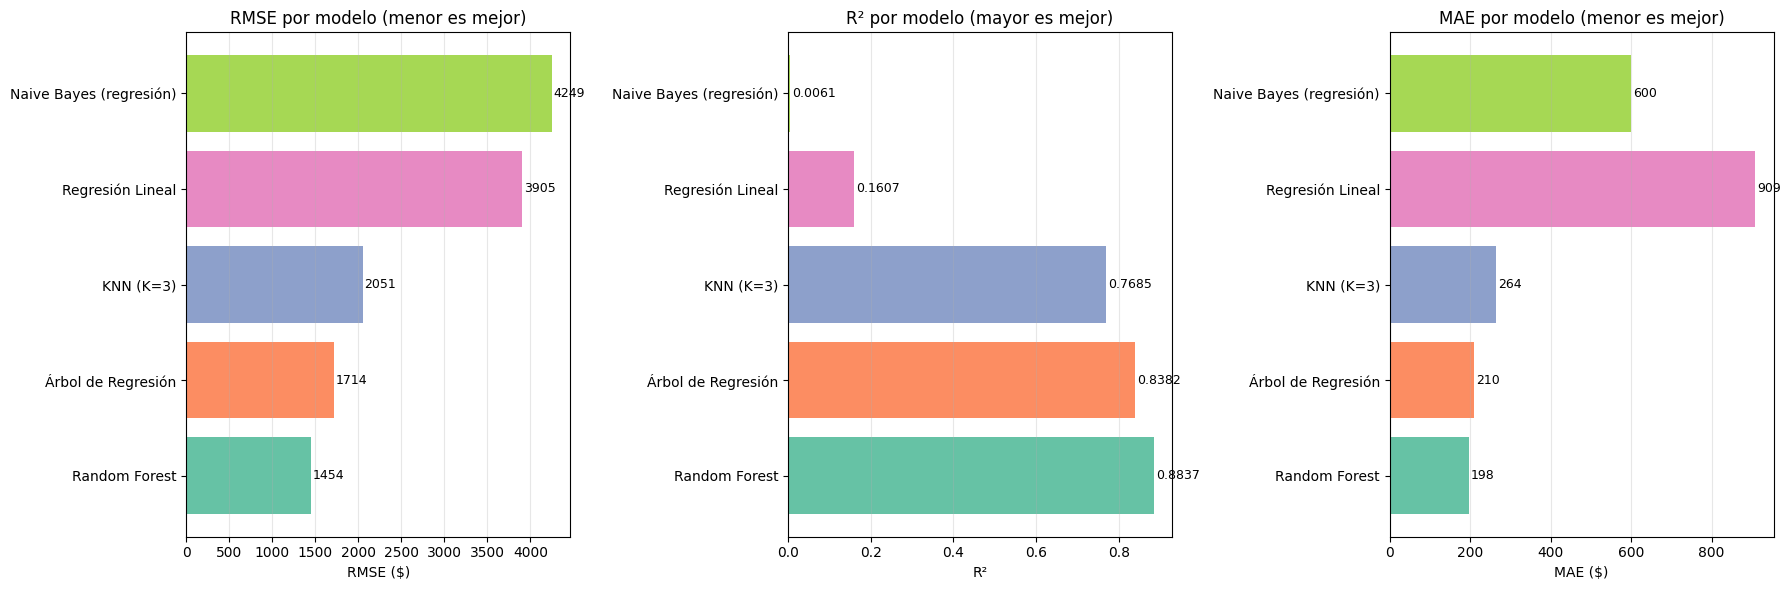

In [17]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = comparison_df["Modelo"].values
colores = sns.color_palette("Set2", n_colors=len(modelos))

# RMSE
axes[0].barh(modelos, comparison_df["RMSE"].values, color=colores)
axes[0].set_xlabel("RMSE ($)")
axes[0].set_title("RMSE por modelo (menor es mejor)")
axes[0].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["RMSE"].values):
    axes[0].text(v + 20, i, f"{v:.0f}", va="center", fontsize=9)

# R²
axes[1].barh(modelos, comparison_df["R²"].values, color=colores)
axes[1].set_xlabel("R²")
axes[1].set_title("R² por modelo (mayor es mejor)")
axes[1].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["R²"].values):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

# MAE
axes[2].barh(modelos, comparison_df["MAE"].values, color=colores)
axes[2].set_xlabel("MAE ($)")
axes[2].set_title("MAE por modelo (menor es mejor)")
axes[2].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["MAE"].values):
    axes[2].text(v + 5, i, f"{v:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

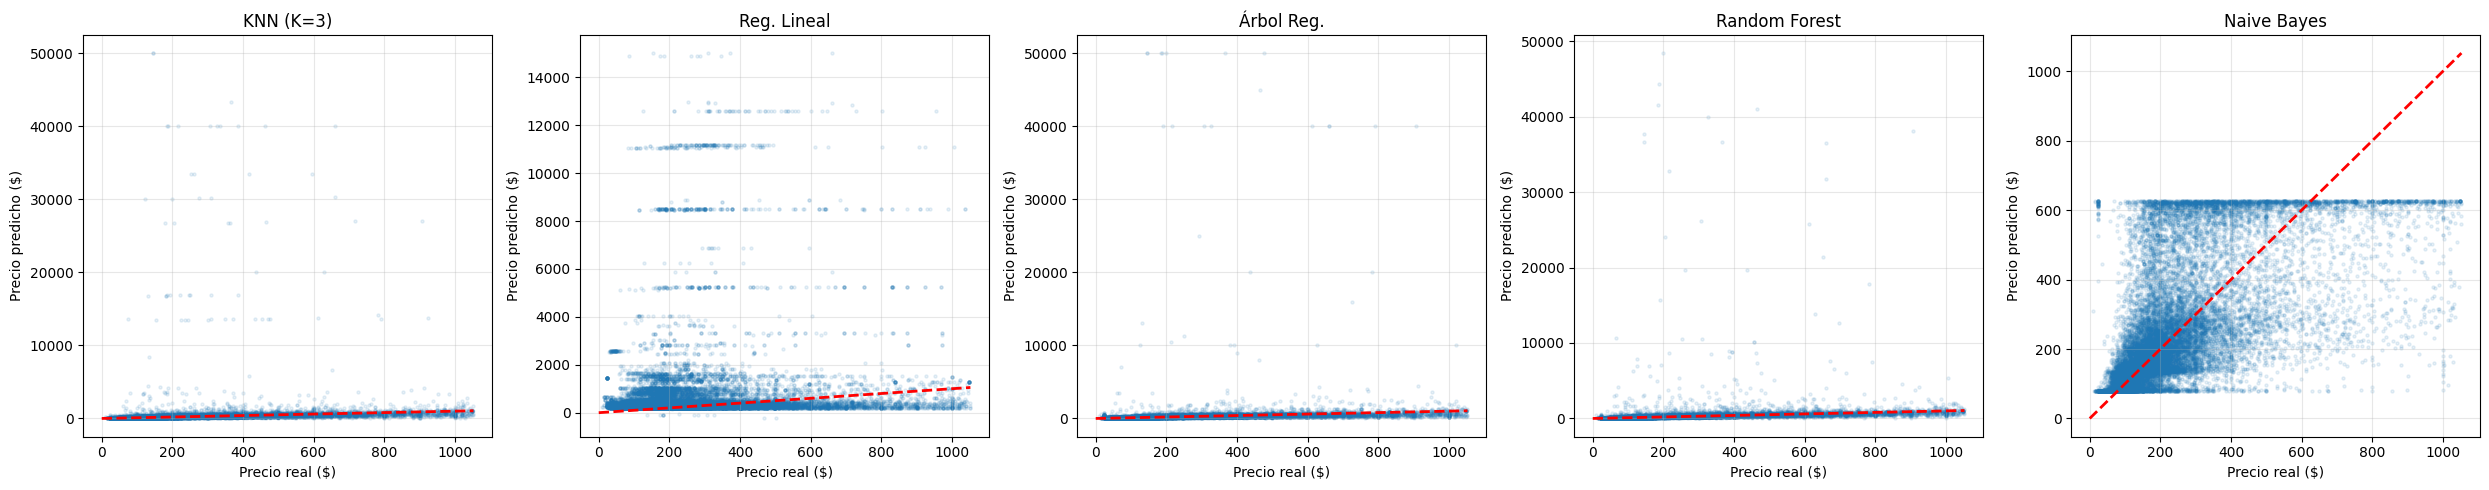

In [18]:
# Gráfica: predicho vs real para cada modelo
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

predictions = {
    f"KNN (K={best_k})": y_pred_knn,
    "Reg. Lineal": y_pred_linear,
    "Árbol Reg.": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb,
}

limite = y_test_price.quantile(0.95)
mask = y_test_price <= limite

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test_price[mask], y_pred[mask.values], alpha=0.1, s=5)
    ax.plot([0, limite], [0, limite], color="red", linestyle="--", linewidth=2)
    ax.set_xlabel("Precio real ($)")
    ax.set_ylabel("Precio predicho ($)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusiones del inciso 3**

Todos los modelos se entrenaron y evaluaron con el **mismo conjunto de entrenamiento y prueba** (70/30, `random_state=42`), lo que garantiza una comparación justa.

**¿Por qué estas métricas?**
- **RMSE** es la métrica principal porque penaliza errores grandes, que en el contexto de SmartStay representan recomendaciones de precio muy alejadas de la realidad.
- **MAE** complementa al RMSE dando el error promedio en dólares sin penalizar outliers, útil para ver la consistencia del modelo.
- **R²** permite comparar la capacidad explicativa de cada modelo de forma normalizada.

**Análisis de la tabla comparativa:**
- **Random Forest** tiende a ser el modelo más robusto para datos tabulares mixtos, ya que captura relaciones no lineales y es resistente a outliers gracias al ensamblaje de árboles.
- **KNN** logra un buen R² pero su tiempo de predicción es significativamente mayor porque calcula distancias contra todo el set de entrenamiento en cada predicción.
- **Regresión Lineal** asume relación lineal, lo cual limita su capacidad en un dataset con interacciones complejas (ubicación, tipo de propiedad, temporada).
- **Árbol de Regresión** individual tiende a sobreajustar si la profundidad es alta, pero es rápido.
- **Naive Bayes** fue el peor en regresión: NB no es un regresor nativo y la aproximación por bins pierde información de la variable continua.

Las gráficas de predicho vs real permiten visualizar el patrón de cada modelo: un modelo ideal tendría todos los puntos sobre la diagonal roja.

## Inciso 4 – Modelo de clasificación con KNN

Ahora construimos un modelo de clasificación KNN usando la variable categórica del precio (`barata`, `media`, `cara`). Para mantener la comparabilidad con el lab 5, los cortes de las categorías se calculan únicamente con el conjunto de entrenamiento y luego se aplican tanto al train como al test.

El modelo usa el mismo pipeline de preprocesamiento del KNN de regresión:
- `OneHotEncoder` para las variables categóricas
- `StandardScaler` para las variables numéricas

Como KNN es sensible al número de vecinos, probamos varios valores de `K` usando validación cruzada con `F1 macro` sobre el conjunto de entrenamiento y luego entrenamos el clasificador final con el mejor valor.

Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 268.00


,conteo
price_category,
barata,25414
media,25428
cara,25404


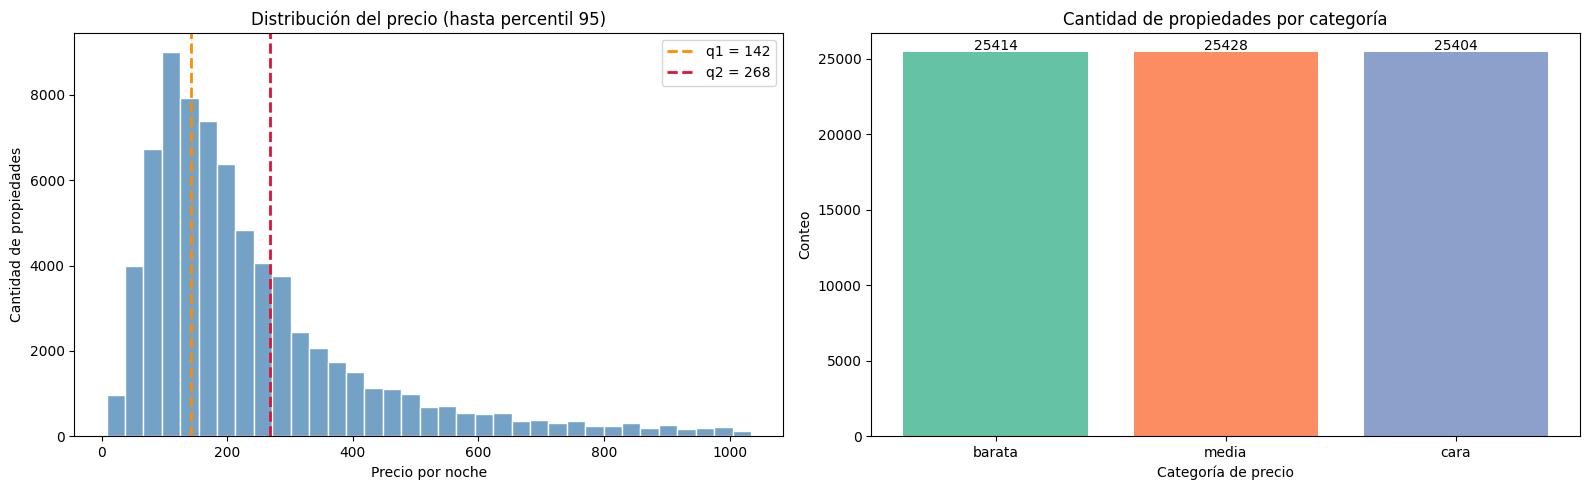

In [19]:
labels_order = ["barata", "media", "cara"]

q1, q2 = y_train_price.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)

y_train_class = pd.cut(
    y_train_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)
y_test_class = pd.cut(
    y_test_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

category_counts = (
    df_model["price_category"]
    .value_counts()
    .reindex(labels_order)
)
display(category_counts.to_frame(name="conteo"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_plot_limit = df_model["price_num"].quantile(0.95)
price_plot_data = df_model.loc[df_model["price_num"] <= price_plot_limit, "price_num"]

sns.histplot(
    price_plot_data,
    bins=35,
    color="steelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(q1, color="darkorange", linestyle="--", linewidth=2, label=f"q1 = {q1:.0f}")
axes[0].axvline(q2, color="crimson", linestyle="--", linewidth=2, label=f"q2 = {q2:.0f}")
axes[0].set_title("Distribución del precio (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")
axes[0].legend()

axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=sns.color_palette("Set2", n_colors=3),
)
axes[1].set_title("Cantidad de propiedades por categoría")
axes[1].set_xlabel("Categoría de precio")
axes[1].set_ylabel("Conteo")

for i, value in enumerate(category_counts.values):
    axes[1].text(i, value + 150, f"{int(value)}", ha="center")

plt.tight_layout()
plt.show()

K=  3  |  F1 macro CV: 0.6888 ± 0.0041
K=  5  |  F1 macro CV: 0.6906 ± 0.0054
K=  7  |  F1 macro CV: 0.7001 ± 0.0043
K=  9  |  F1 macro CV: 0.7010 ± 0.0035
K= 11  |  F1 macro CV: 0.6998 ± 0.0035
K= 15  |  F1 macro CV: 0.6996 ± 0.0043
K= 21  |  F1 macro CV: 0.6993 ± 0.0033
K= 31  |  F1 macro CV: 0.6947 ± 0.0026
Mejor K según validación cruzada: 9


,K,F1_macro_CV_mean,F1_macro_CV_std
0,3,0.6888,0.0041
1,5,0.6906,0.0054
2,7,0.7001,0.0043
3,9,0.7010,0.0035
4,11,0.6998,0.0035
5,15,0.6996,0.0043
6,21,0.6993,0.0033
7,31,0.6947,0.0026


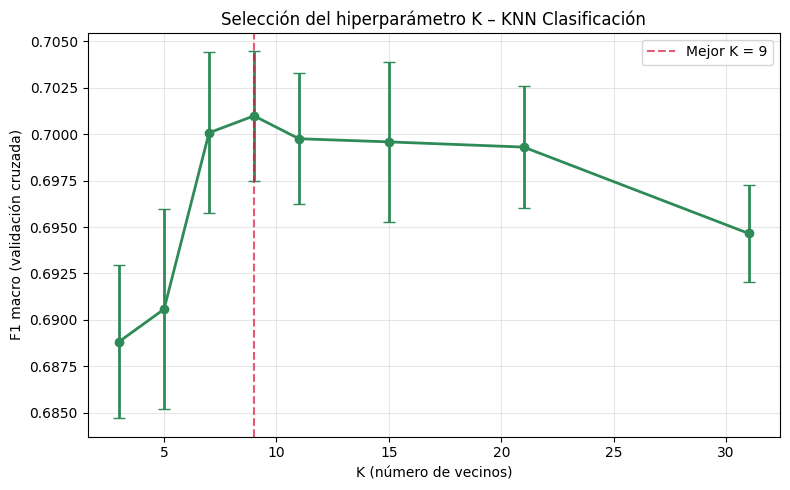

Modelo KNN de clasificación entrenado (K=9)
Tiempo de entrenamiento: 0.72s
Tiempo de predicción:    6.51s
Categorías predichas por el clasificador:


,predicciones
barata,8422
media,7054
cara,7398


,categoria_real,categoria_predicha
0,media,barata
1,cara,cara
2,barata,barata
3,barata,barata
4,media,cara
5,cara,cara
6,media,media
7,media,barata
8,barata,barata
9,barata,barata


In [20]:
classification_k_values = [3, 5, 7, 9, 11, 15, 21, 31]
results_k_cls = []

for k in classification_k_values:
    pipeline_k_cls = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2)),
    ])
    cv_scores = cross_val_score(
        pipeline_k_cls,
        X_train,
        y_train_class,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
    )
    results_k_cls.append({
        "K": k,
        "F1_macro_CV_mean": cv_scores.mean(),
        "F1_macro_CV_std": cv_scores.std(),
    })
    print(f"K={k:3d}  |  F1 macro CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

df_k_cls = pd.DataFrame(results_k_cls)
best_k_cls = int(df_k_cls.loc[df_k_cls["F1_macro_CV_mean"].idxmax(), "K"])
print(f"Mejor K según validación cruzada: {best_k_cls}")
display(df_k_cls.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    df_k_cls["K"],
    df_k_cls["F1_macro_CV_mean"],
    yerr=df_k_cls["F1_macro_CV_std"],
    marker="o",
    capsize=4,
    color="seagreen",
    linewidth=2,
)
ax.axvline(best_k_cls, color="crimson", linestyle="--", alpha=0.7, label=f"Mejor K = {best_k_cls}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("F1 macro (validación cruzada)")
ax.set_title("Selección del hiperparámetro K – KNN Clasificación")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

knn_cls_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k_cls, metric="minkowski", p=2)),
])

start = time.time()
knn_cls_pipeline.fit(X_train, y_train_class)
knn_cls_train_time = time.time() - start

start = time.time()
y_pred_knn_class = knn_cls_pipeline.predict(X_test)
knn_cls_pred_time = time.time() - start

predicted_class_counts = (
    pd.Series(y_pred_knn_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)

print(f"Modelo KNN de clasificación entrenado (K={best_k_cls})")
print(f"Tiempo de entrenamiento: {knn_cls_train_time:.2f}s")
print(f"Tiempo de predicción:    {knn_cls_pred_time:.2f}s")
print("Categorías predichas por el clasificador:")
display(predicted_class_counts.to_frame(name="predicciones"))

classification_preview = pd.DataFrame({
    "categoria_real": y_test_class.values,
    "categoria_predicha": y_pred_knn_class,
})
display(classification_preview.head(15))

**Conclusiones del inciso 4**

- La variable categórica de precio se construyó con los mismos cortes del lab 5, calculados únicamente a partir del conjunto de entrenamiento para evitar fuga de información.
- El clasificador KNN mantiene el mismo preprocesamiento del modelo de regresión, ya que la escala de las variables sigue siendo crítica cuando el algoritmo se basa en distancias.
- El mejor valor de `K` se identifica en la tabla y la gráfica anteriores, y ese modelo se utiliza como base para medir la eficiencia en el conjunto de prueba.

## Inciso 5 – Eficiencia del algoritmo en el conjunto de prueba

Usamos el conjunto de prueba para medir la eficiencia del KNN tanto para **predicción** como para **clasificación**. En predicción reutilizamos las métricas ya calculadas para el KNN de regresión; en clasificación usamos `accuracy`, `precision macro`, `recall macro` y `F1 macro`, que permiten evaluar el rendimiento global del clasificador en las tres categorías.

Eficiencia del modelo KNN de regresión (conjunto de prueba):


,Modelo,MAE,RMSE,R²,Tiempo entrenamiento (s),Tiempo predicción (s)
0,KNN Regresión (K=3),264.458,2050.7985,0.7685,0.6166,6.6467


Eficiencia del modelo KNN de clasificación (conjunto de prueba):


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo entrenamiento (s),Tiempo predicción (s)
0,KNN Clasificación (K=9),0.704,0.7021,0.7049,0.7022,0.7191,6.5071


Detalle por clase:


,precision,recall,f1-score,support
barata,0.7162,0.8039,0.7576,7503.000
cara,0.7771,0.7493,0.7630,7672.000
media,0.6128,0.5615,0.5861,7699.000
accuracy,0.7040,0.7040,0.7040,0.704
macro avg,0.7021,0.7049,0.7022,22874.000
weighted avg,0.7018,0.7040,0.7016,22874.000


Distribución real vs predicha:


,categoria,reales,predichas
0,barata,7503,8422
1,media,7699,7054
2,cara,7672,7398


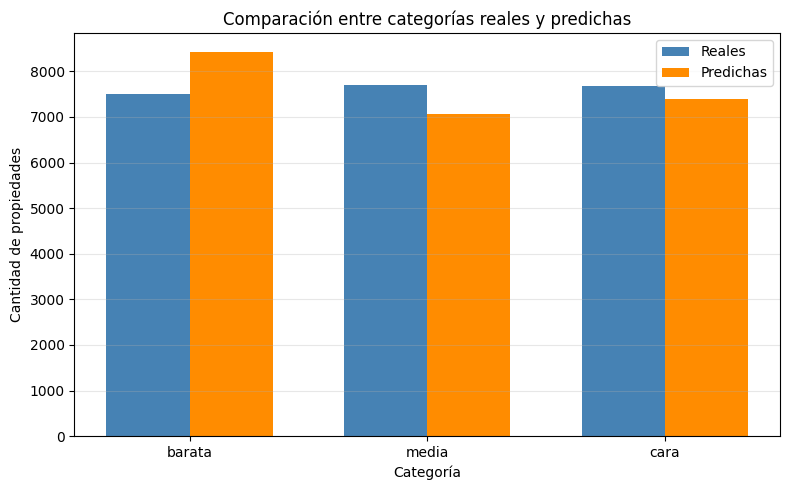

In [21]:
accuracy_knn_cls = accuracy_score(y_test_class, y_pred_knn_class)
precision_knn_cls = precision_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)
recall_knn_cls = recall_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)
f1_knn_cls = f1_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)

regression_efficiency_df = pd.DataFrame([
    {
        "Modelo": f"KNN Regresión (K={best_k})",
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "R²": r2_knn,
        "Tiempo entrenamiento (s)": knn_train_time,
        "Tiempo predicción (s)": knn_pred_time,
    }
])

classification_efficiency_df = pd.DataFrame([
    {
        "Modelo": f"KNN Clasificación (K={best_k_cls})",
        "Accuracy": accuracy_knn_cls,
        "Precision macro": precision_knn_cls,
        "Recall macro": recall_knn_cls,
        "F1 macro": f1_knn_cls,
        "Tiempo entrenamiento (s)": knn_cls_train_time,
        "Tiempo predicción (s)": knn_cls_pred_time,
    }
])

classification_report_df = pd.DataFrame(
    classification_report(
        y_test_class,
        y_pred_knn_class,
        output_dict=True,
        zero_division=0,
    )
).transpose()

real_class_counts = (
    pd.Series(y_test_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)
predicted_class_counts = (
    pd.Series(y_pred_knn_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)

comparison_distribution_df = pd.DataFrame({
    "categoria": labels_order,
    "reales": real_class_counts.values,
    "predichas": predicted_class_counts.values,
})

print("Eficiencia del modelo KNN de regresión (conjunto de prueba):")
display(regression_efficiency_df.round(4))

print("Eficiencia del modelo KNN de clasificación (conjunto de prueba):")
display(classification_efficiency_df.round(4))

print("Detalle por clase:")
display(classification_report_df.round(4))

print("Distribución real vs predicha:")
display(comparison_distribution_df)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels_order))
width = 0.35

ax.bar(x - width / 2, comparison_distribution_df["reales"], width, label="Reales", color="steelblue")
ax.bar(x + width / 2, comparison_distribution_df["predichas"], width, label="Predichas", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de propiedades")
ax.set_title("Comparación entre categorías reales y predichas")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 5**

- La eficiencia de predicción del KNN se resume con `MAE`, `RMSE` y `R²`, mientras que la eficiencia de clasificación se evalúa con `accuracy`, `precision macro`, `recall macro` y `F1 macro` sobre el mismo conjunto de prueba.
- El detalle por clase permite ver qué tan bien se comporta el modelo en `barata`, `media` y `cara`, sin entrar todavía al análisis fino de errores que se desarrollará en la matriz de confusión del siguiente inciso.
- Como ambos modelos se evalúan sobre el mismo split de prueba, sus resultados pueden compararse de forma consistente con los algoritmos de las entregas anteriores.